In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import joblib
import pickle  # For loading .pkl files
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder

In [15]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset.csv')
X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
# Load the XGBoost model and label encoder
try:
    xgboost_model = joblib.load("../../../models/xgboost/xgboost_model_label_v3.joblib")
    print("XGBoost model loaded successfully")
except:
    print("Error loading XGBoost model")

# Try to load the label encoder (.pkl file)
try:
    with open("../../../data/processed/label_encoders_selected.pkl", 'rb') as f:
        label_encoder = pickle.load(f)
    print("Label encoder (.pkl) loaded successfully")
except FileNotFoundError:
    print("Label encoder (.pkl) not found, using original string values")
    label_encoder = None
except Exception as e:
    print(f"Error loading label encoder: {str(e)}")
    label_encoder = None

XGBoost model loaded successfully
Label encoder (.pkl) loaded successfully


In [17]:
y_pred_test = xgboost_model.predict(X_test)

In [18]:
# Function to decode labels if encoder exists
def decode_labels(encoded_values, encoder):
    if encoder is None:
        return encoded_values
    try:
        # Handle both numeric and string encoded values
        if pd.api.types.is_numeric_dtype(encoded_values):
            return encoder.inverse_transform(encoded_values.astype(int))
        else:
            return encoded_values
    except Exception as e:
        print(f"Error decoding labels: {str(e)}")
        return encoded_values


In [19]:
# Create analysis directory
analysis_dir = "../../../reports/address_analysis/"
os.makedirs(analysis_dir, exist_ok=True)

In [20]:
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_test
})

# Add address information (handle both encoded and decoded cases)
if 'address_line_2' in X_test.columns:
    results_df['address_encoded'] = X_test['address_line_2'].values
    results_df['address'] = decode_labels(results_df['address_encoded'], label_encoder)
else:
    results_df['address'] = 'Unknown'


Error decoding labels: 'numpy.ndarray' object has no attribute 'inverse_transform'



Address metrics saved to ../../../reports/address_analysis/address_performance_metrics.csv

Address Performance Summary:
                       Top Performing Addresses                       
 Address       R2        MAE  Sample_Size  Actual_Mean  Predicted_Mean
    84.0 0.959750  80.821839            7  4026.975714     3998.712158
    86.0 0.933237  84.938334           19  2879.700526     2849.895752
     8.0 0.931884  62.915583           12  3795.152500     3831.938232
    23.0 0.927593  50.108805           20  1450.408000     1439.734863
    45.0 0.914865  80.716569           52  2936.398654     2942.642090
    50.0 0.911005  92.894912           10  3843.148000     3896.189941
    78.0 0.884858 108.040820           36  3123.304722     3060.155273
    30.0 0.881551  40.700744           19  1273.551053     1269.184570
    81.0 0.880609 123.805835           42  5674.310952     5679.064941
    10.0 0.871265 121.169023            4  3812.517500     3933.686523

                     Bott

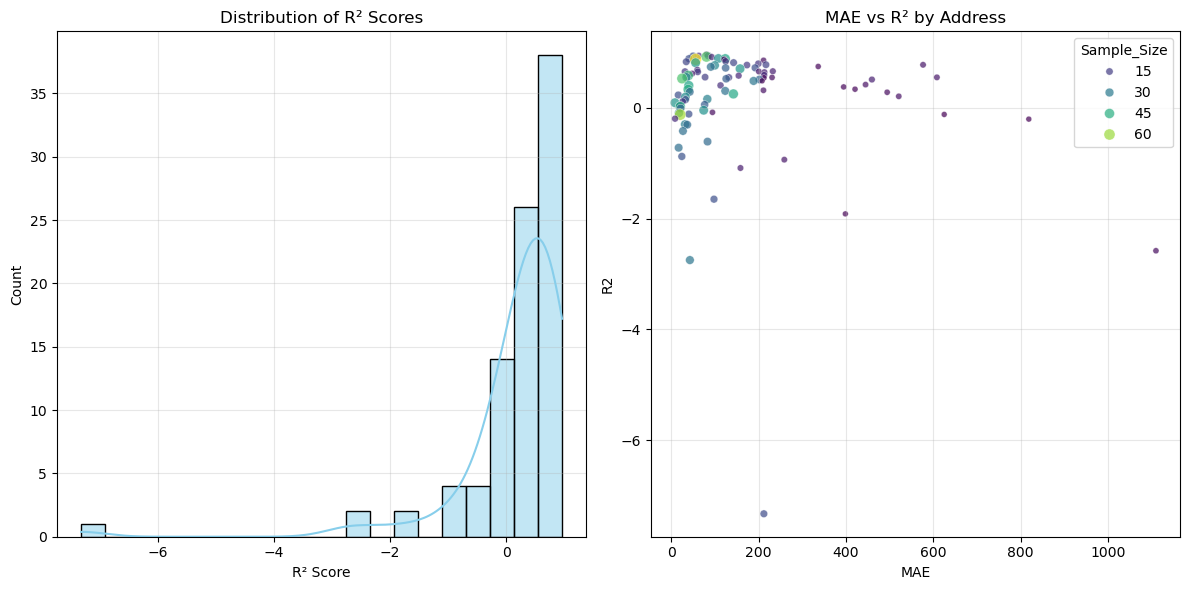


Creating detailed address plots...
Detailed plots saved to ../../../reports/address_analysis/


In [21]:
# Calculate metrics for each address
if 'address' in results_df.columns:
    address_metrics = []
    
    # Group by address and calculate metrics
    for address, group in results_df.groupby('address'):
        if len(group) >= 3:  # Minimum 3 samples per address
            r2 = r2_score(group['actual'], group['predicted'])
            mae = mean_absolute_error(group['actual'], group['predicted'])
            address_metrics.append({
                'Address': address,
                'R2': r2,
                'MAE': mae,
                'Sample_Size': len(group),
                'Actual_Mean': group['actual'].mean(),
                'Predicted_Mean': group['predicted'].mean()
            })
    
    # Create and sort metrics DataFrame
    metrics_df = pd.DataFrame(address_metrics).sort_values('R2', ascending=False)
    
    # Save metrics to CSV
    metrics_csv_path = os.path.join(analysis_dir, 'address_performance_metrics.csv')
    metrics_df.to_csv(metrics_csv_path, index=False)
    print(f"\nAddress metrics saved to {metrics_csv_path}")
    
    # Print performance summary
    print("\nAddress Performance Summary:")
    print("=" * 70)
    print(f"{'Top Performing Addresses':^70}")
    print("=" * 70)
    print(metrics_df.head(10).to_string(index=False))
    
    print("\n" + "=" * 70)
    print(f"{'Bottom Performing Addresses':^70}")
    print("=" * 70)
    print(metrics_df.tail(10).to_string(index=False))
    
    # Create visualizations
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(metrics_df['R2'], bins=20, kde=True, color='skyblue')
    plt.title('Distribution of R² Scores')
    plt.xlabel('R² Score')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    sns.scatterplot(data=metrics_df, x='MAE', y='R2', size='Sample_Size', 
                    hue='Sample_Size', palette='viridis', alpha=0.7)
    plt.title('MAE vs R² by Address')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(analysis_dir, 'address_performance_summary.png'))
    plt.show()
    
    # Create detailed address plots (top and bottom 5)
    print("\nCreating detailed address plots...")
    for address in list(metrics_df.head(5)['Address']) + list(metrics_df.tail(5)['Address']):
        addr_data = results_df[results_df['address'] == address]
        
        plt.figure(figsize=(10, 6))
        plt.scatter(addr_data['actual'], addr_data['predicted'], alpha=0.6, color='blue')
        plt.plot([addr_data['actual'].min(), addr_data['actual'].max()],
                 [addr_data['actual'].min(), addr_data['actual'].max()], 'r--')
        
        metrics = metrics_df[metrics_df['Address'] == address].iloc[0]
        plt.title(f"Address: {address}\n"
                 f"R²: {metrics['R2']:.3f} | MAE: {metrics['MAE']:.2f} | "
                 f"Samples: {metrics['Sample_Size']}")
        plt.xlabel('Actual Price per m²')
        plt.ylabel('Predicted Price per m²')
        plt.grid(True, alpha=0.3)
        
        # Save plot
        safe_name = "".join(c if c.isalnum() else "_" for c in str(address))
        plt.savefig(os.path.join(analysis_dir, f'address_{safe_name}.png'), bbox_inches='tight')
        plt.close()
    
    print(f"Detailed plots saved to {analysis_dir}")
else:
    print("\nNo address information available for analysis")

In [22]:
# Print overall performance
overall_r2 = r2_score(results_df['actual'], results_df['predicted'])
overall_mae = mean_absolute_error(results_df['actual'], results_df['predicted'])

print("\n" + "=" * 70)
print(f"{'Overall Model Performance':^70}")
print("=" * 70)
print(f"R²: {overall_r2:.4f}")
print(f"MAE: {overall_mae:.4f}")
print(f"Number of addresses analyzed: {len(metrics_df) if 'address' in results_df.columns else 0}")


                      Overall Model Performance                       
R²: 0.9920
MAE: 96.9227
Number of addresses analyzed: 91


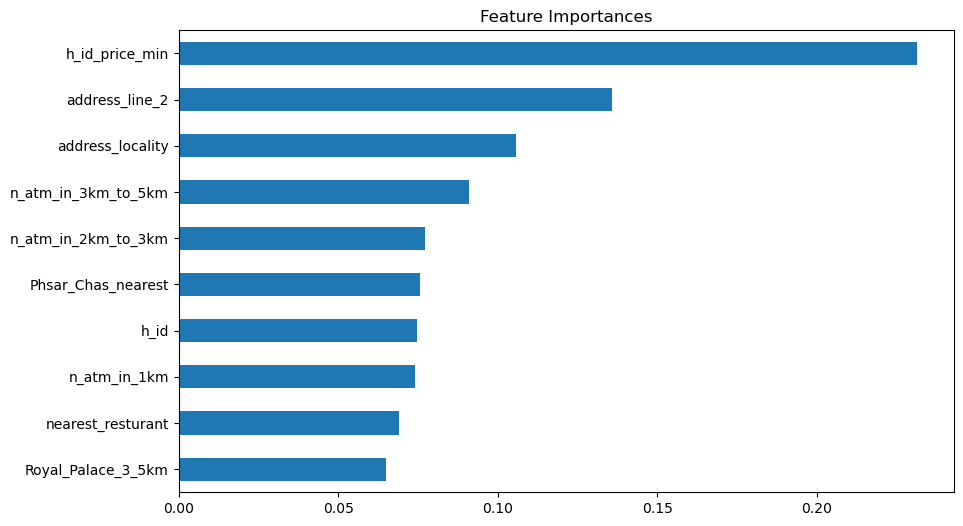

In [27]:
if hasattr(xgboost_model, 'feature_importances_'):
    importances = pd.Series(
        xgboost_model.feature_importances_, 
        index=X_train.columns
    ).sort_values(ascending=True)
    
    plt.figure(figsize=(10, 6))
    importances.plot(kind='barh')
    plt.title("Feature Importances")
    plt.show()